# Illustration de la distinction grands fonds / petits fonds en acoustique sous-marine

In [56]:
import os 
import sys
import numpy as np

import matplotlib.pyplot as plt

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

# Load usefull functions
import source.global_constants as g

from publication.publication_figure import PubFigure, LargeFigure, SmallFigure
pfig = PubFigure()

folder_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\illustration\general_ocean_acoustics"

## Profondeur de séparation en environnement grand fond et petit fond 

$\overline{D} = \frac{\sqrt{\lambda R}}{D}$


In [57]:
# Propriétés 
fmax = 50   # Hz 
df = 0.1
r = 30 * 1e3 # m
dmax = 5000    #m
dz = 1

In [58]:
depth = np.arange(dz, dmax+dz, dz)
freq = np.arange(df, fmax+df, df)
l = g.c0 / freq

D_bar_lim = np.sqrt(l * r) 

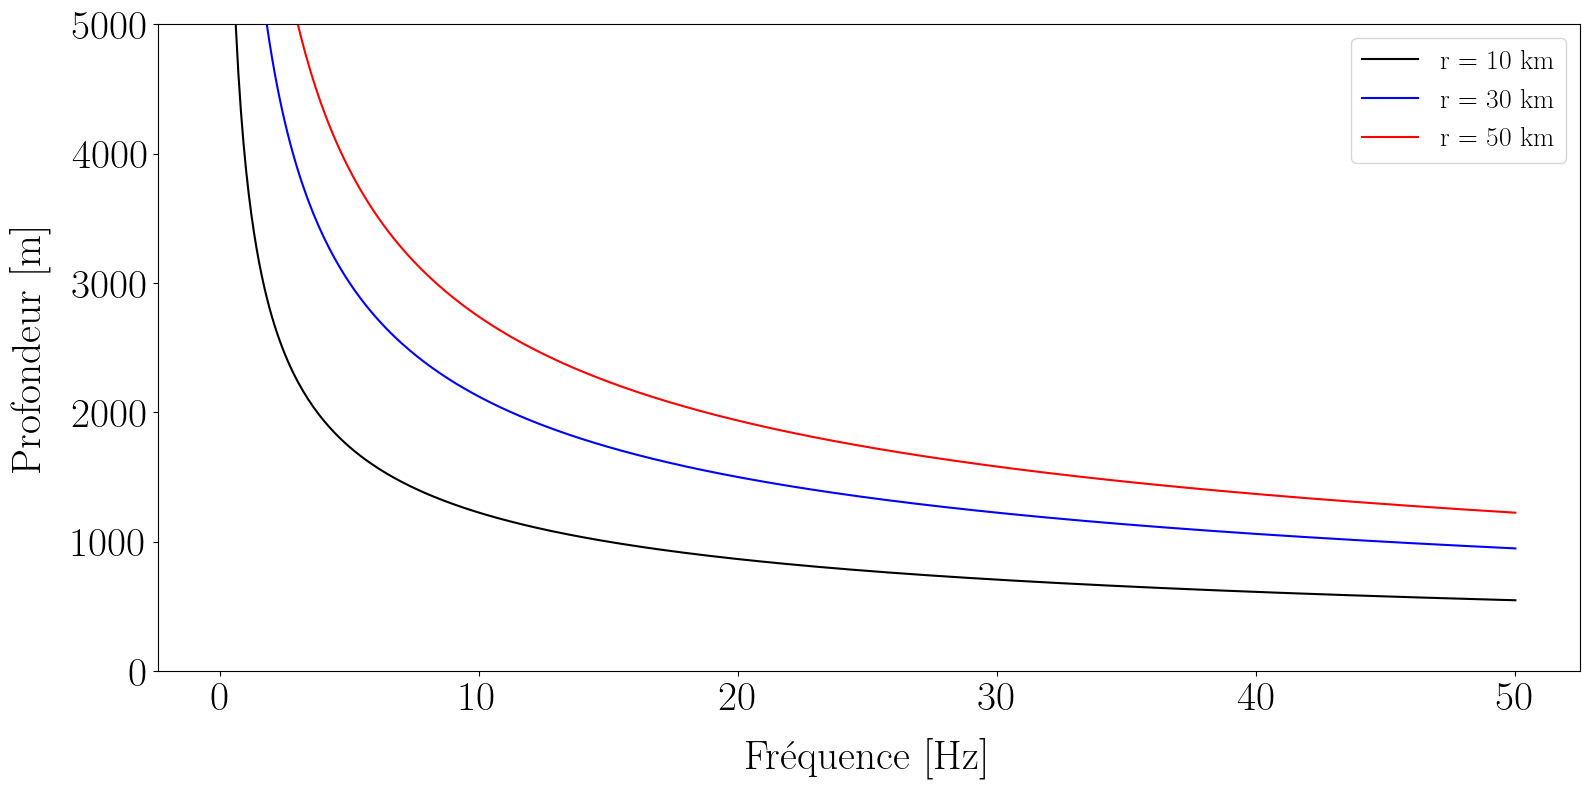

In [59]:
# Plot
colors = ["k", "b", "r"]
plt.figure()
for r_km in [10, 30, 50]:
    D_bar_lim = np.sqrt(l * r_km*1e3)
    plt.plot(freq, D_bar_lim, label=f"r = {r_km} km", color=colors.pop(0))
plt.xlabel("Fréquence [Hz]")
plt.ylabel("Profondeur [m]")
plt.ylim([0, dmax])

plt.legend()

# Save 
fpath = os.path.join(folder_root, "dw_sw_depthlim_freq.pdf")
plt.savefig(fpath, dpi=300)

(0.0, 5000.0)

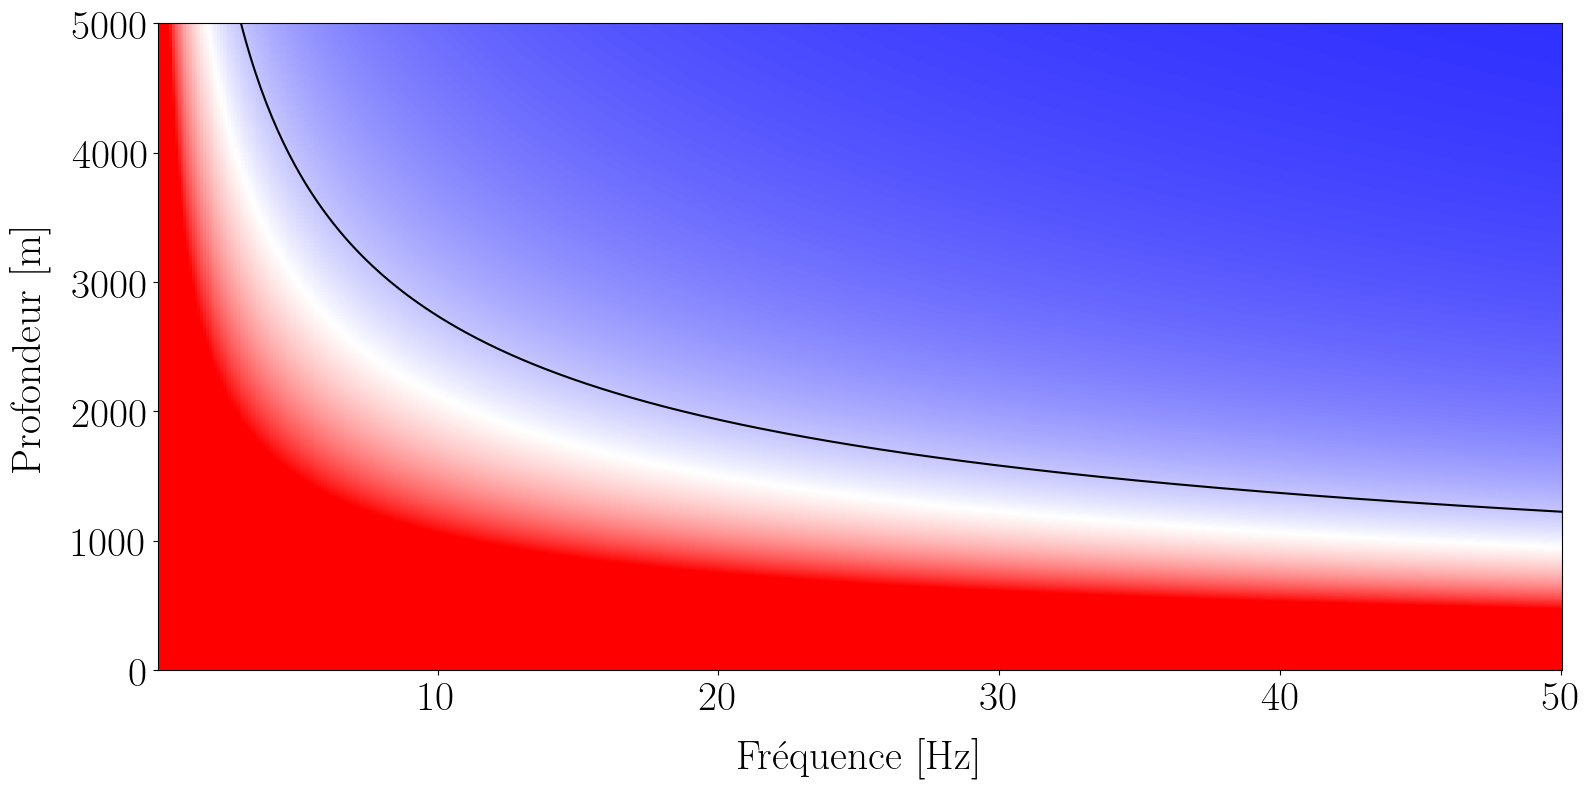

In [60]:
ll, zz = np.meshgrid(l, depth)

dd_bar = np.sqrt(ll*r) / zz - 1

plt.figure()
plt.pcolormesh(freq, depth, dd_bar, vmin=-1, vmax=1, cmap="bwr")
plt.plot(freq, D_bar_lim, color="k")
plt.xlabel("Fréquence [Hz]")
plt.ylabel("Profondeur [m]")
plt.ylim([0, dmax])